## Photo Classification by genre
### Resnet 18 experiments
#### Experiments for the other models with ResNet18 with smaller (8500) dataset
#### Test datas:
###### Name: Sándor Balázs
###### Neptun ID: AZA6NL
###### Network: ResNet18
###### Objects: PhotoDB

### GitHub repository for the assignment:
https://github.com/SandorBalazsHU/elte-ik-msc-thesis
### The own dataset:
https://drive.google.com/drive/folders/1tI_4lpFtdm3cvkHvUJw7WzLzZ1Wb7iIp?usp=sharing

## 1. Import libraries
Import all libraries/packages and initialize the device. (CUDA in tis case)

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler # customize the training
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
import warnings
warnings.filterwarnings("ignore") 

print(torch.cuda.is_available())
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
torch.zeros(1).cuda()

True
cuda:0


tensor([0.], device='cuda:0')

## 2. Dataset
Loading the dataset, split it and introduce it.

### The dataset's structure.
My dataset created by me from my own photo library. I chose 8500 photos from my phot library and i categorized them by 16 genre, i wrote a script wich can convert the Nikon raw .nef format to .jpg and resize the images to 224 with for the ResNet. Then i wrote a script wich rename the images and an another wich split the images to training, test and validation set (50-25-25).

The used scripts are available in the project repository.

The selected classes:

aircraft_in_air, aircraft_on_ground, animal, architecture, astro, fireworks, forest, interior, item, landscape, macro, music, nature, people, street, vehicle

The used dataset sizes:

train: 4246

validation: 2119

test: 213    

### Batch size
I have a 4GB GPU, for this size the 64 batch seemed size is ideal for two modells and a correct running time.

### Image transformation
Because the ResNet18 model is designed for images of size 224, I scale it to that size and then do random transformations.

### Pre-processing the dataset (data loader with transformations)

In [2]:
Batch_size=64;

#Size 224 is ideal for ResNet18
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomAffine(degrees=(5, 50), translate=(0.1, 0.3), scale=(0.9, 1.1)),
        transforms.RandomPerspective(distortion_scale=0.2),
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'sample_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val', 'test']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=Batch_size, shuffle=True, num_workers=4) for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
print("Readed classes: ")
print(class_names)
print("Readed dataset sizes: ")
print(dataset_sizes)

Readed classes: 
['aircraft_in_air', 'aircraft_on_ground', 'animal', 'architecture', 'astro', 'fireworks', 'forest', 'interior', 'item', 'landscape', 'macro', 'music', 'nature', 'people', 'street', 'vehicle']
Readed dataset sizes: 
{'train': 4247, 'val': 2119, 'test': 2135}


### Showing some images and labels

In [3]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)

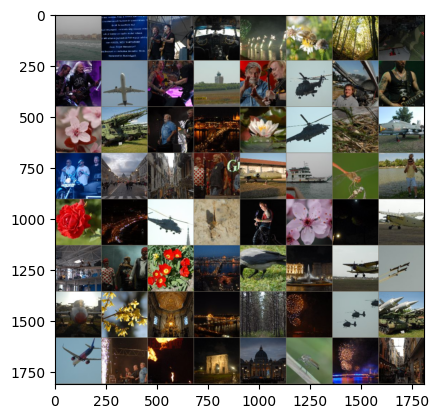

In [4]:
# Get a batch of training data
inputs, classes = next(iter(dataloaders['val']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out)

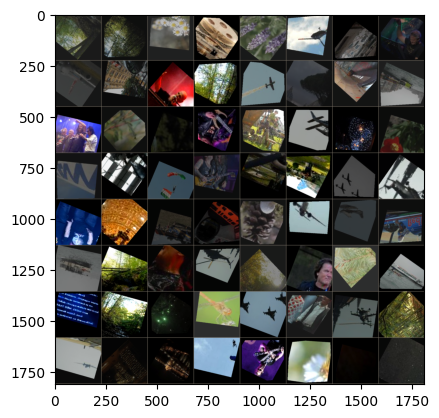

In [5]:
# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out)

## 3. Convolutional Neural Network Architecture
Load the pre-trained CNN architecture you were given.

### Load the given pre-trained model

In [6]:
model = models.resnet18()

#### Summary of the given pre-trained model

ResNet18 Architecture

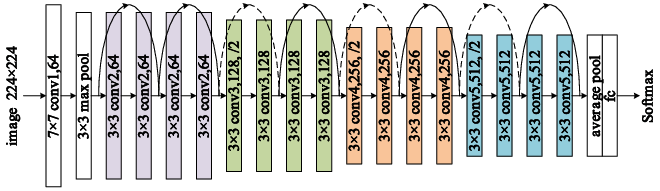

In [7]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Create the model trainer method.

In [8]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    val_acc_h=[]
    train_acc_h=[]
    for epoch in range(num_epochs):
        print('-' * 10)    
        print('--> Epoch {}/{} LR {:.6f}'.format(epoch, num_epochs - 1, scheduler.get_last_lr()[0]))

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode
            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()
                
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))
            if phase == 'train':
                train_acc_h.append(epoch_acc)
            # deep copy the model
            if phase == 'val':
                val_acc_h.append(epoch_acc)
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print('Test started')
    phase == 'test'
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    for inputs, labels in dataloaders[phase]:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        test_loss = running_loss / dataset_sizes[phase]
        test_acc = running_corrects.double() / dataset_sizes[phase]
        
    time_elapsed = time.time() - since
    print('-' * 10)
    print('Training and testing complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    print('Test Acc: {:4f}'.format(test_acc))
    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, val_acc_h, train_acc_h, test_acc

### Build the basic model.

In [9]:
#Random weights for the modell
model = models.resnet18()
numrs = model.fc.in_features

model.fc = nn.Linear(numrs, len(class_names))
model = model.to(device)

#CrossEntropyLoss loss function
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

### ---> Load the own retrained modell and skip the training

In [10]:
model.load_state_dict(torch.load('resnet_trained/resnet18_basic.pth'))

<All keys matched successfully>

### <--- Run the training

In [10]:
model, val_acc_h, train_acc_h, test_acc = train_model(model, criterion, optimizer, exp_lr_scheduler,
                       num_epochs=10)

----------
--> Epoch 0/9 LR 0.000100
train Loss: 1.9687 Acc: 0.4097
val Loss: 1.6944 Acc: 0.4738
----------
--> Epoch 1/9 LR 0.000100
train Loss: 1.5503 Acc: 0.5157
val Loss: 1.3627 Acc: 0.5828
----------
--> Epoch 2/9 LR 0.000100
train Loss: 1.3937 Acc: 0.5524
val Loss: 1.3323 Acc: 0.5866
----------
--> Epoch 3/9 LR 0.000100
train Loss: 1.3387 Acc: 0.5696
val Loss: 1.2319 Acc: 0.5899
----------
--> Epoch 4/9 LR 0.000100
train Loss: 1.2972 Acc: 0.5825
val Loss: 1.1797 Acc: 0.6357
----------
--> Epoch 5/9 LR 0.000100
train Loss: 1.2620 Acc: 0.5931
val Loss: 1.0348 Acc: 0.6767
----------
--> Epoch 6/9 LR 0.000100
train Loss: 1.2173 Acc: 0.6150
val Loss: 0.9548 Acc: 0.7131
----------
--> Epoch 7/9 LR 0.000010
train Loss: 1.1206 Acc: 0.6381
val Loss: 0.8721 Acc: 0.7263
----------
--> Epoch 8/9 LR 0.000010
train Loss: 1.0615 Acc: 0.6581
val Loss: 0.8546 Acc: 0.7334
----------
--> Epoch 9/9 LR 0.000010
train Loss: 1.0694 Acc: 0.6621
val Loss: 0.8648 Acc: 0.7272
Test started
----------
Traini

#### A modell state_dict-jének mentése

In [11]:
torch.save(model.state_dict(), 'resnet_trained/resnet18_basic.pth')

### Plot the training resoults

In [12]:
def plot_acc(train_acc_h,val_acc_h, test_acc): 
    plt.figure(figsize=(10,6))
    plt.xlabel('Iteration')
    plt.ylabel('Acc')
    plt.title('Acc by Iteration')
    plt.plot(torch.tensor(train_acc_h, device = 'cpu')*100)
    plt.plot(torch.tensor(val_acc_h, device = 'cpu')*100)
    plt.plot(torch.tensor(test_acc, device = 'cpu')*100*np.ones(len(val_acc_h)))
    plt.ylim((50,100))
    plt.legend(['train', 'valid', 'test'])

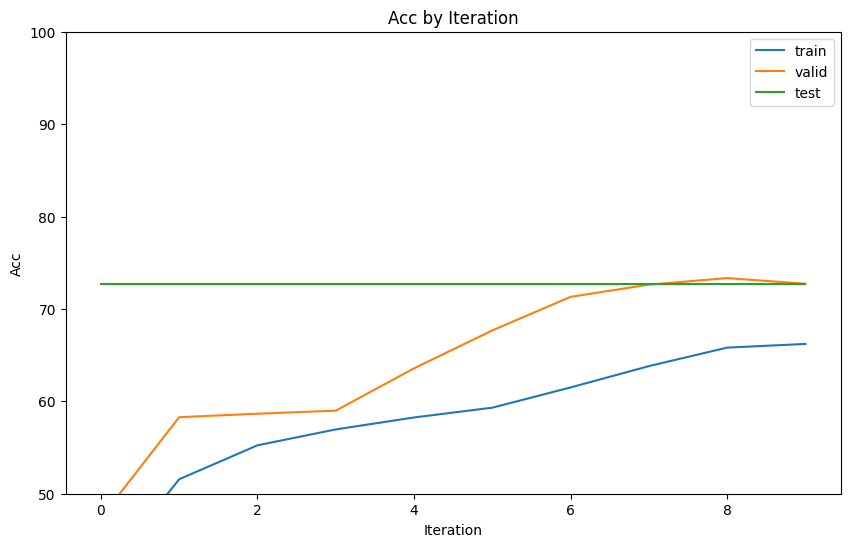

In [13]:
plot_acc(train_acc_h,val_acc_h, test_acc)

### Confusion matrix test

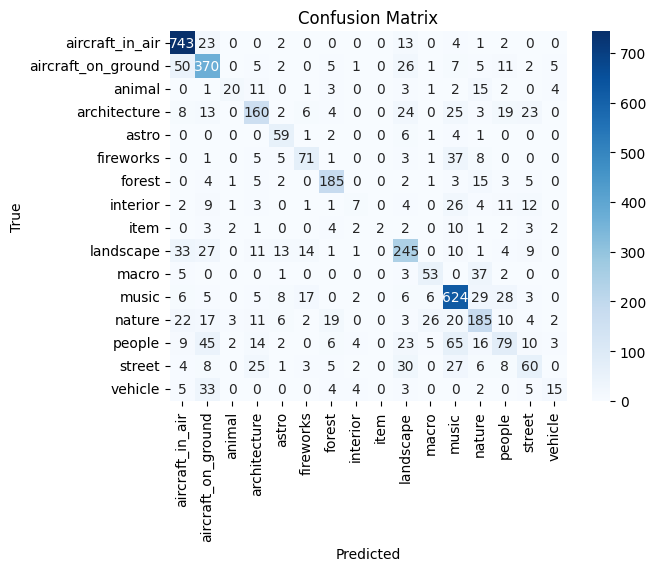

In [14]:
import torch
from sklearn.metrics import confusion_matrix
import pandas as pd
from pretty_confusion_matrix import pp_matrix
import seaborn as sns

def evaluate_model(model, dataloaders, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloaders['train']:  # Test dataset betöltése
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

# Kód a confusion mátrix létrehozásához és megjelenítéséhez
labels, preds = evaluate_model(model, dataloaders, device)
cm = confusion_matrix(labels, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Visualize some resoults

In [20]:
def visualize_model(model, num_images=10):
    was_training = model.training
    model.eval()
    images_so_far = 0

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                fig = plt.figure(figsize=(10,10))
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

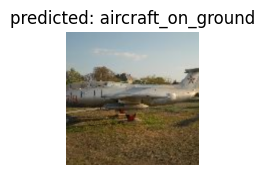

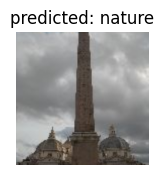

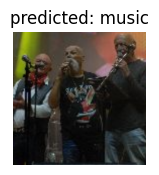

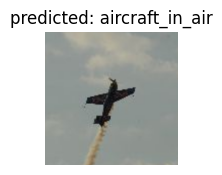

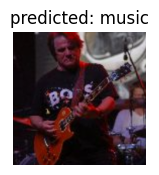

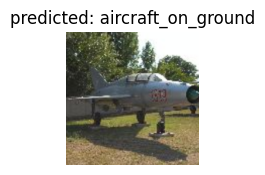

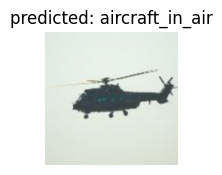

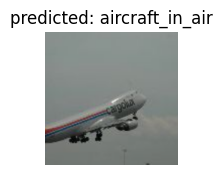

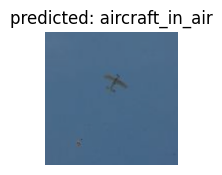

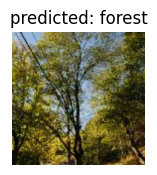

In [21]:
visualize_model(model)

### 4. Implement the new architecture with less parameter

### The finetuned modell

In [23]:
#Pretrained from ImageNet.
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 5.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device)

#Same loss function
criterion = nn.CrossEntropyLoss() # BinaryCrossEntropyLoss

#SGD OPTIMIZER
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

### ---> Load the own retrained modell and skip the training

In [ ]:
model.load_state_dict(torch.load('resnet_trained/resnet18_basic_2.pth'))

### <-- Run the learning

In [24]:
model_ft, val_acc_h, train_acc_h, test_acc = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=10)

----------
--> Epoch 0/9 LR 0.001000
train Loss: 1.9028 Acc: 0.4396
val Loss: 1.1184 Acc: 0.6862
----------
--> Epoch 1/9 LR 0.001000
train Loss: 1.1468 Acc: 0.6614
val Loss: 0.7667 Acc: 0.7711
----------
--> Epoch 2/9 LR 0.001000
train Loss: 0.9171 Acc: 0.7212
val Loss: 0.6479 Acc: 0.8065
----------
--> Epoch 3/9 LR 0.001000
train Loss: 0.8054 Acc: 0.7565
val Loss: 0.5410 Acc: 0.8362
----------
--> Epoch 4/9 LR 0.001000
train Loss: 0.7398 Acc: 0.7683
val Loss: 0.5287 Acc: 0.8230
----------
--> Epoch 5/9 LR 0.001000
train Loss: 0.6900 Acc: 0.7860
val Loss: 0.4367 Acc: 0.8655
----------
--> Epoch 6/9 LR 0.001000
train Loss: 0.6371 Acc: 0.8008
val Loss: 0.4097 Acc: 0.8759
----------
--> Epoch 7/9 LR 0.000100
train Loss: 0.5973 Acc: 0.8187
val Loss: 0.3978 Acc: 0.8759
----------
--> Epoch 8/9 LR 0.000100
train Loss: 0.6170 Acc: 0.8076
val Loss: 0.3914 Acc: 0.8797
----------
--> Epoch 9/9 LR 0.000100
train Loss: 0.5974 Acc: 0.8185
val Loss: 0.3904 Acc: 0.8759
Test started
----------
Traini

#### A modell state_dict-jének mentése 2

In [25]:
torch.save(model.state_dict(), 'resnet_trained/resnet18_basic_2.pth')

### Plot the new accurency. It is better? YES!

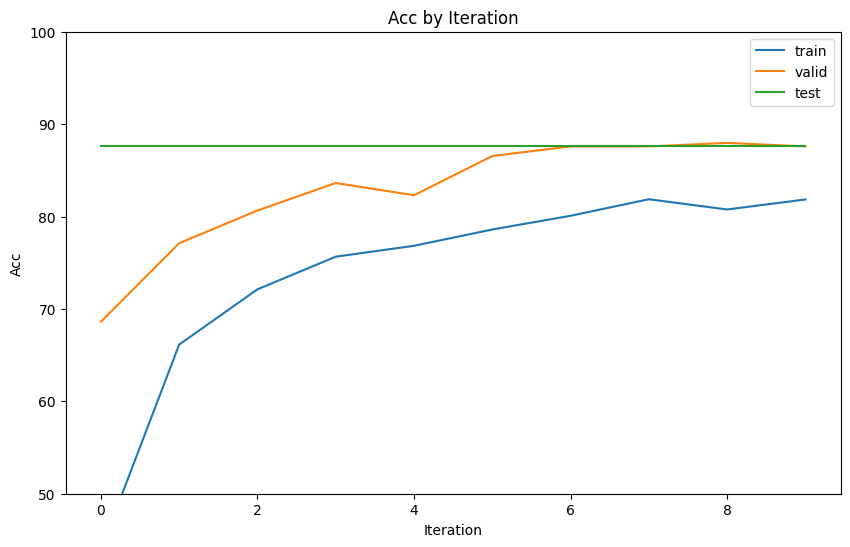

In [26]:
plot_acc(train_acc_h,val_acc_h, test_acc)

### <---> Confusion matrix test

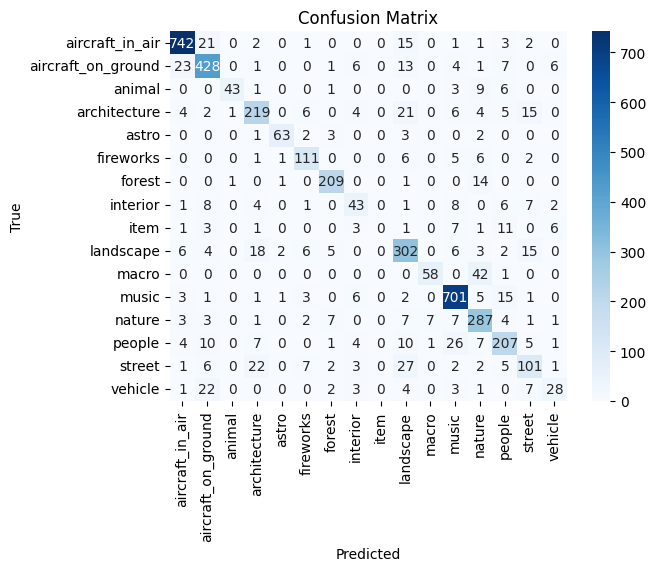

In [33]:
# Kód a confusion mátrix létrehozásához és megjelenítéséhez
labels, preds = evaluate_model(model_ft, dataloaders, device)
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Show some resoults.

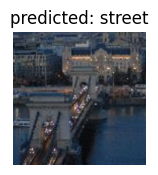

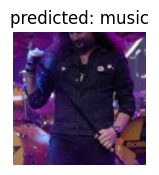

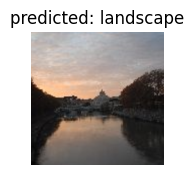

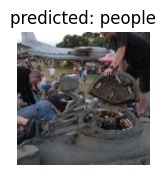

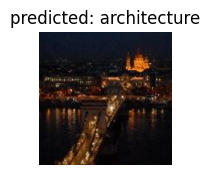

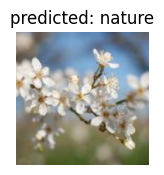

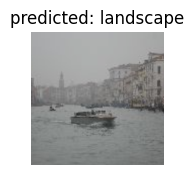

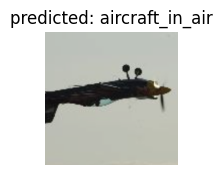

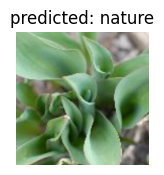

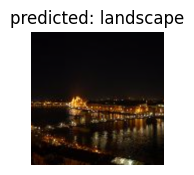

In [28]:
visualize_model(model_ft)

## 5. Another optimalization
### ConvNet as fixed feature extractor - Transfer Learning

In [39]:
model_conv = torchvision.models.resnet18(pretrained=True) ## PRETRAINED!!!
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, len(class_names))

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [40]:
model_conv, val_acc_h, train_acc_h, test_acc = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=10)

----------
--> Epoch 0/9 LR 0.001000
train Loss: 2.1768 Acc: 0.3595
val Loss: 1.6831 Acc: 0.5262
----------
--> Epoch 1/9 LR 0.001000
train Loss: 1.6450 Acc: 0.5411
val Loss: 1.3609 Acc: 0.6135
----------
--> Epoch 2/9 LR 0.001000
train Loss: 1.4066 Acc: 0.6058
val Loss: 1.1920 Acc: 0.6649
----------
--> Epoch 3/9 LR 0.001000
train Loss: 1.3011 Acc: 0.6244
val Loss: 1.1089 Acc: 0.6763
----------
--> Epoch 4/9 LR 0.001000
train Loss: 1.2138 Acc: 0.6574
val Loss: 1.0123 Acc: 0.7060
----------
--> Epoch 5/9 LR 0.001000
train Loss: 1.1600 Acc: 0.6600
val Loss: 0.9548 Acc: 0.7197
----------
--> Epoch 6/9 LR 0.001000
train Loss: 1.1203 Acc: 0.6727
val Loss: 0.9112 Acc: 0.7286
----------
--> Epoch 7/9 LR 0.000100
train Loss: 1.0874 Acc: 0.6859
val Loss: 0.9194 Acc: 0.7230
----------
--> Epoch 8/9 LR 0.000100
train Loss: 1.0623 Acc: 0.6826
val Loss: 0.8777 Acc: 0.7423
----------
--> Epoch 9/9 LR 0.000100
train Loss: 1.0506 Acc: 0.6988
val Loss: 0.9003 Acc: 0.7338
Test started
----------
Traini

#### Modell mentése

In [52]:
torch.save(model.state_dict(), 'resnet_trained/resnet18_basic_3.pth')

In [44]:
plot_acc(train_acc_h,val_acc_h, test_acc)

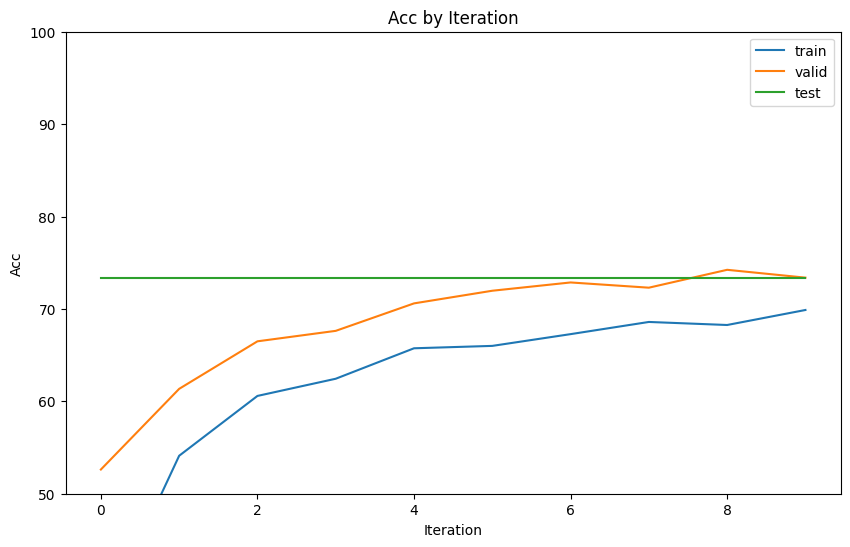

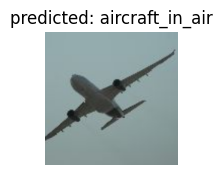

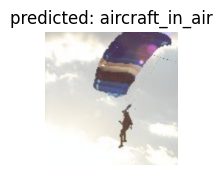

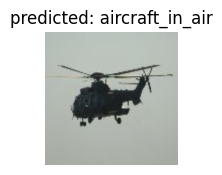

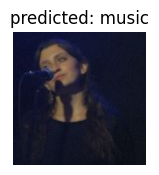

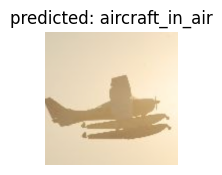

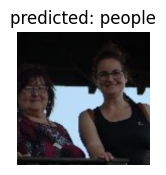

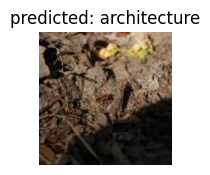

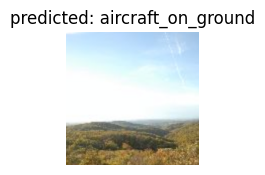

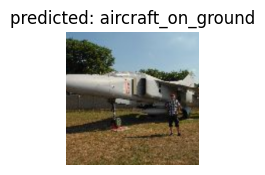

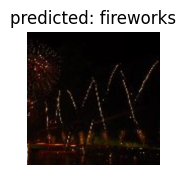

In [45]:
visualize_model(model_conv)

plt.ioff()
plt.show()

### <---> Confusion matrix test

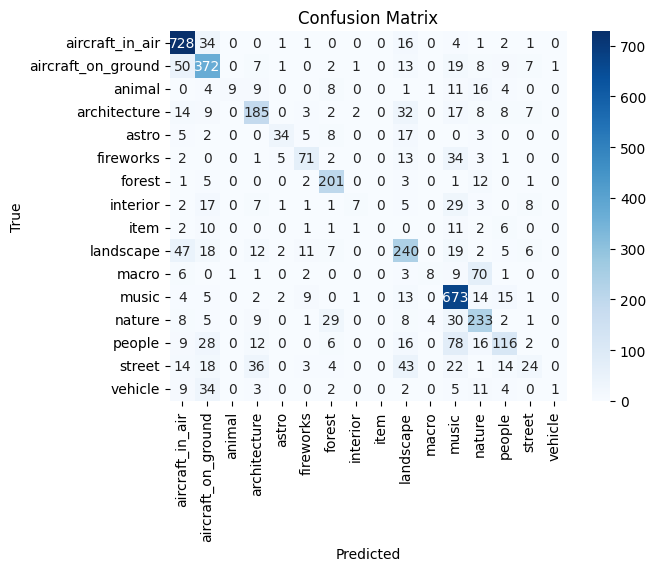

In [46]:
# Kód a confusion mátrix létrehozásához és megjelenítéséhez
labels, preds = evaluate_model(model_conv, dataloaders, device)
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## 6. Another optimalization
### Then finetuning the entire network

In [47]:
model_conv2 = torchvision.models.resnet18(pretrained=True)
for param in model_conv2.parameters():
    param.requires_grad = True

num_ftrs2 = model_conv2.fc.in_features
model_conv2.fc = nn.Linear(num_ftrs2, len(class_names))

model_conv2 = model_conv.to(device)

criterion2 = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv_2 = optim.SGD(model_conv2.fc.parameters(), lr=0.00001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler_2 = lr_scheduler.StepLR(optimizer_conv_2, step_size=7, gamma=0.1)

In [48]:
model_conv2, val_acc_h, train_acc_h, test_acc = train_model(model_conv2, criterion2, optimizer_conv_2, exp_lr_scheduler_2, num_epochs=10)

----------
--> Epoch 0/9 LR 0.000010
train Loss: 1.0759 Acc: 0.6894
val Loss: 0.9021 Acc: 0.7357
----------
--> Epoch 1/9 LR 0.000010
train Loss: 1.0795 Acc: 0.6802
val Loss: 0.9077 Acc: 0.7334
----------
--> Epoch 2/9 LR 0.000010
train Loss: 1.0835 Acc: 0.6751
val Loss: 0.8897 Acc: 0.7409
----------
--> Epoch 3/9 LR 0.000010
train Loss: 1.0674 Acc: 0.6826
val Loss: 0.9046 Acc: 0.7291
----------
--> Epoch 4/9 LR 0.000010
train Loss: 1.0800 Acc: 0.6890
val Loss: 0.8914 Acc: 0.7367
----------
--> Epoch 5/9 LR 0.000010
train Loss: 1.0681 Acc: 0.6861
val Loss: 0.9145 Acc: 0.7310
----------
--> Epoch 6/9 LR 0.000010
train Loss: 1.0684 Acc: 0.6868
val Loss: 0.8952 Acc: 0.7334
----------
--> Epoch 7/9 LR 0.000001
train Loss: 1.0705 Acc: 0.6897
val Loss: 0.9081 Acc: 0.7291
----------
--> Epoch 8/9 LR 0.000001
train Loss: 1.0728 Acc: 0.6890
val Loss: 0.8967 Acc: 0.7362
----------
--> Epoch 9/9 LR 0.000001
train Loss: 1.0619 Acc: 0.6883
val Loss: 0.9168 Acc: 0.7268
Test started
----------
Traini

#### Modell saving

In [54]:
torch.save(model.state_dict(), 'resnet_trained/resnet18_basic_4.pth')

In [49]:
plot_acc(train_acc_h,val_acc_h, test_acc)

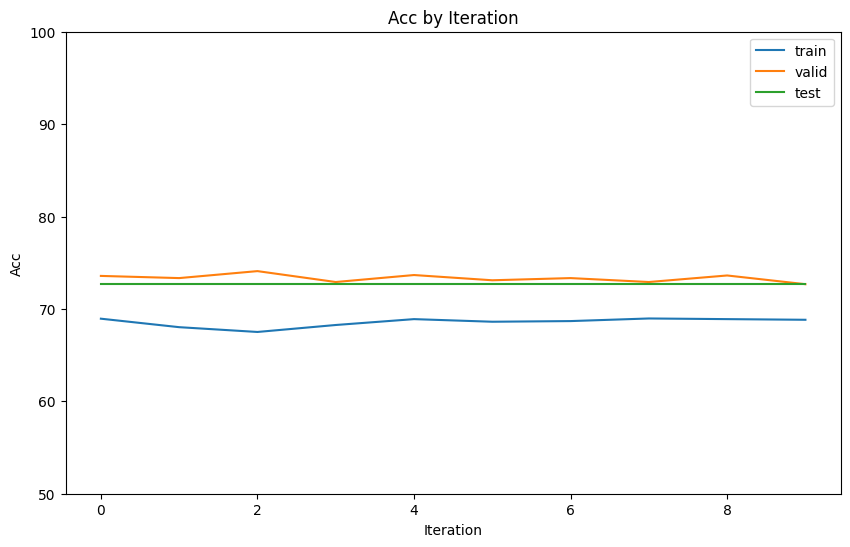

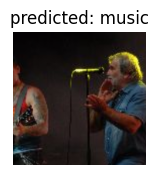

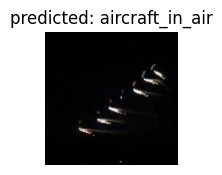

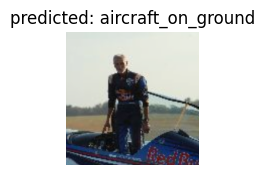

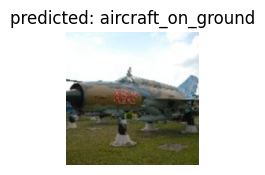

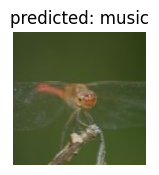

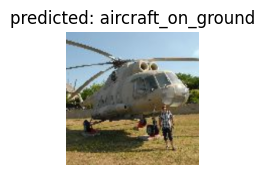

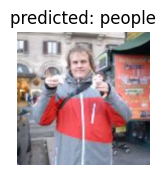

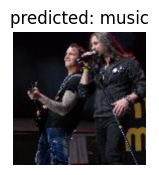

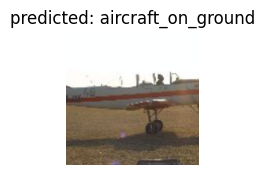

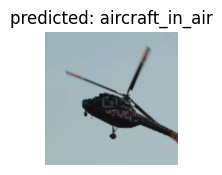

In [50]:
visualize_model(model_conv2)

plt.ioff()
plt.show()

### <---> Confusion matrix test

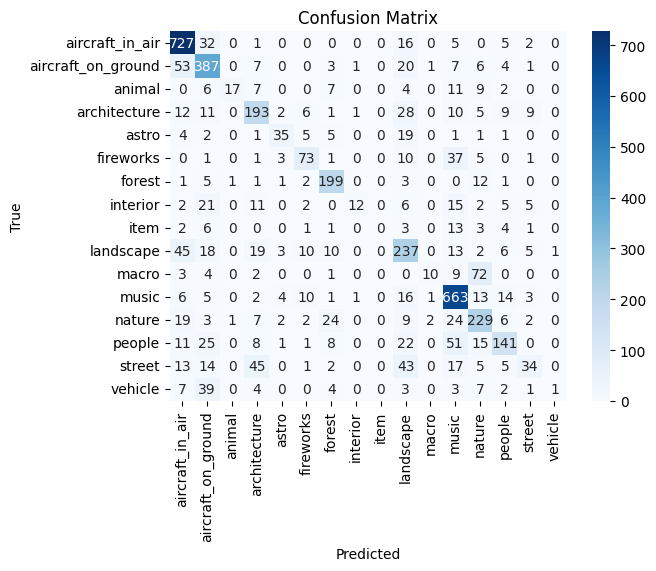

In [51]:
# Kód a confusion mátrix létrehozásához és megjelenítéséhez
labels, preds = evaluate_model(model_conv2, dataloaders, device)
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# The END